In [1]:
pip install mlxtend

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

from mlxtend.plotting import plot_decision_regions
import missingno as msno
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [50]:
diabetes_df = pd.read_csv('diabetes.csv')
diabetes_df.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
2,183,64,0,0,23.3,0.672,32,1
3,89,66,23,94,28.1,0.167,21,0
4,137,40,35,168,43.1,2.288,33,1


In [51]:
diabetes_df.columns

Index(['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
       'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [52]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Glucose                   768 non-null    int64  
 1   BloodPressure             768 non-null    int64  
 2   SkinThickness             768 non-null    int64  
 3   Insulin                   768 non-null    int64  
 4   BMI                       768 non-null    float64
 5   DiabetesPedigreeFunction  768 non-null    float64
 6   Age                       768 non-null    int64  
 7   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 48.1 KB


In [53]:
diabetes_df.describe()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [54]:
diabetes_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [55]:
diabetes_df.isnull().head(10)

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False


In [56]:
diabetes_df.isnull().sum()

Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [57]:
diabetes_df_copy = diabetes_df.copy(deep=True)
columns_to_replace = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
diabetes_df_copy[columns_to_replace] = diabetes_df_copy[columns_to_replace].replace(0, np.NaN)
print(diabetes_df_copy.isnull().sum())

Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


array([[<Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>,
        <Axes: title={'center': 'SkinThickness'}>],
       [<Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>,
        <Axes: title={'center': 'DiabetesPedigreeFunction'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>, <Axes: >]], dtype=object)

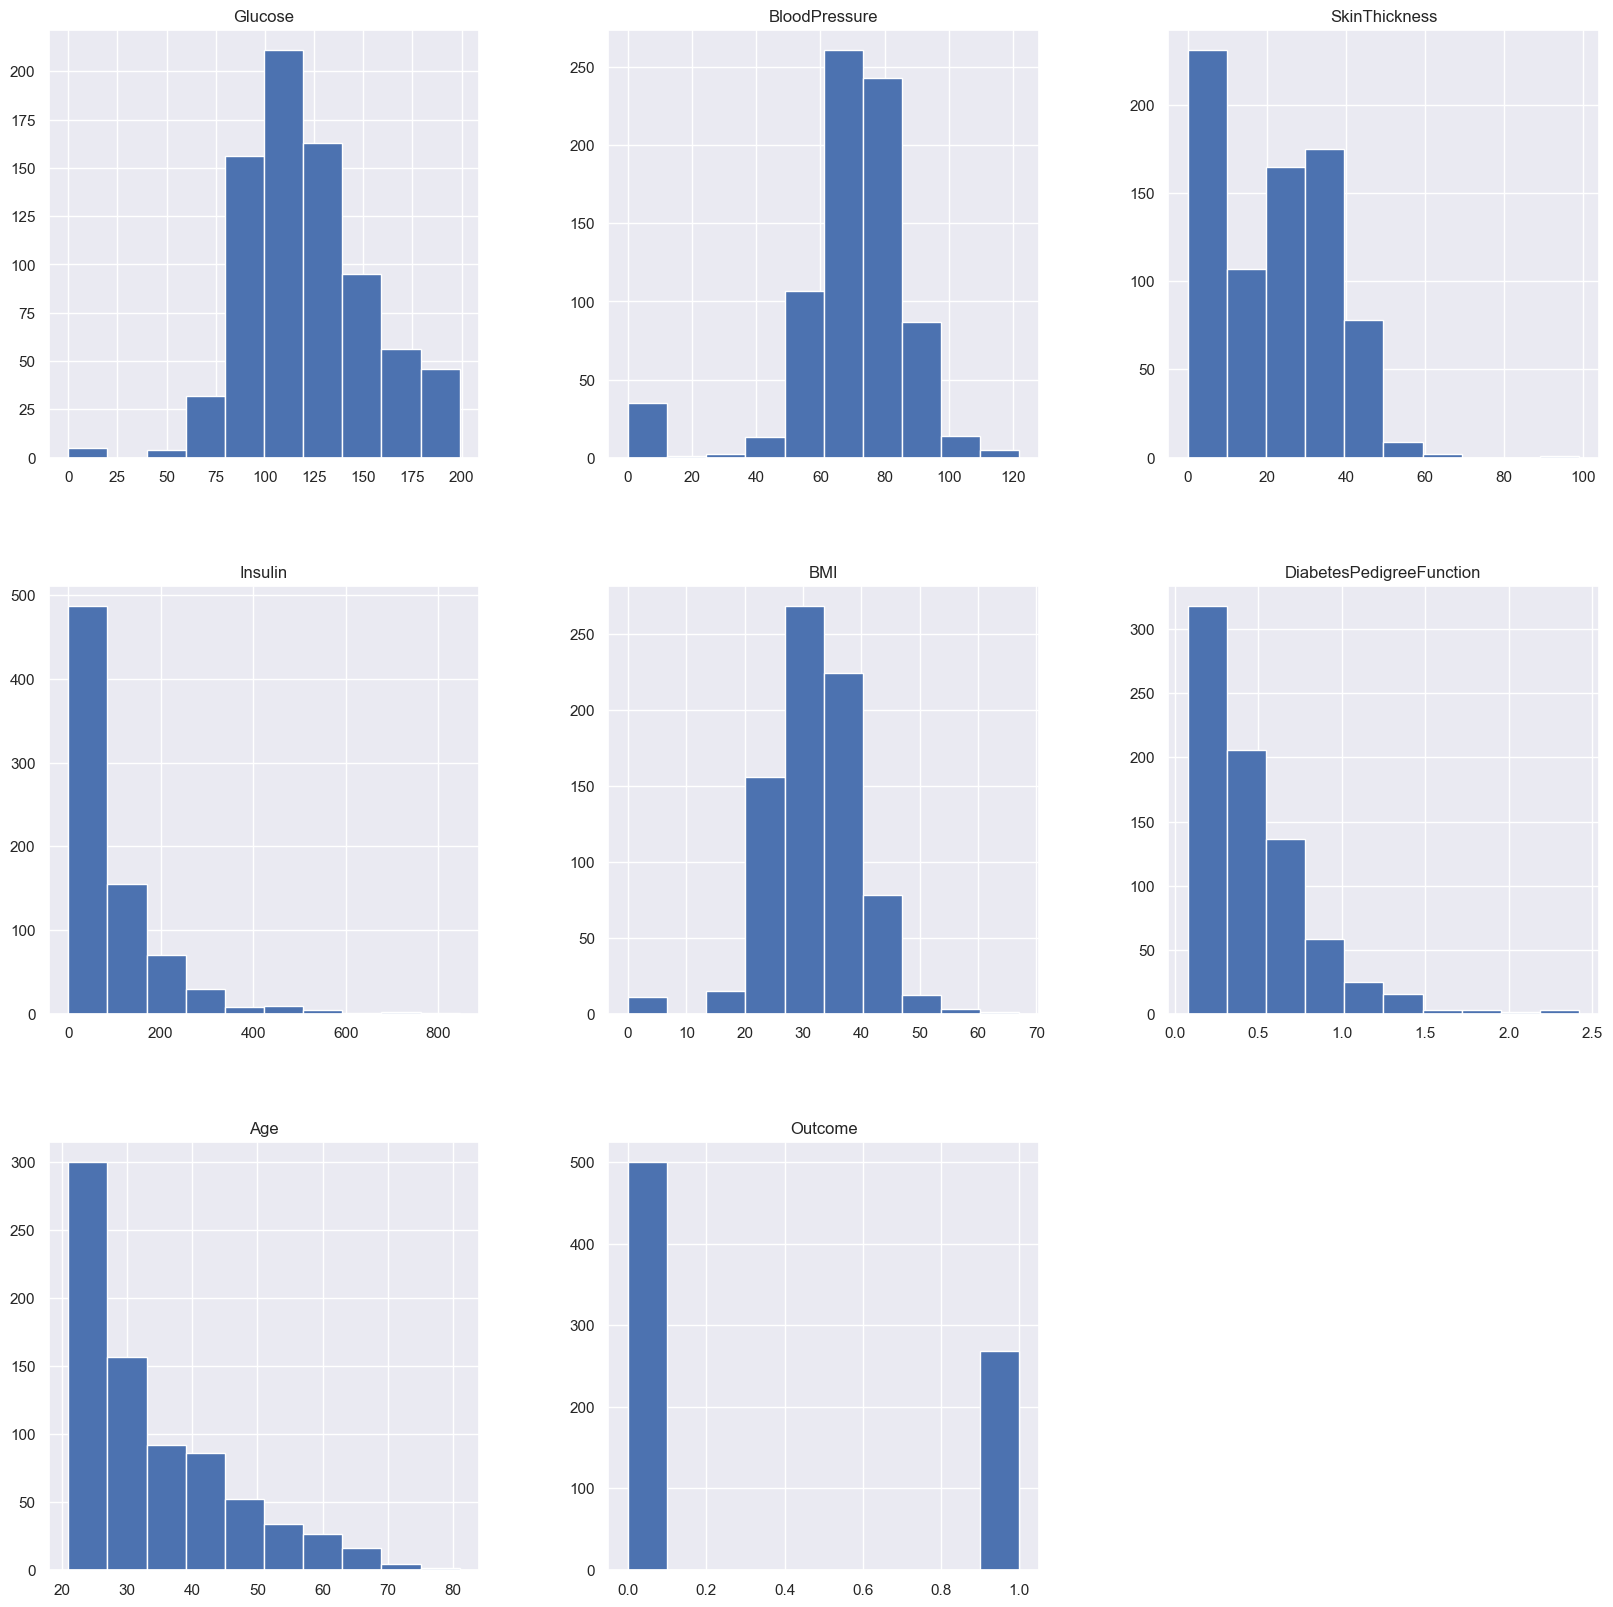

In [58]:
diabetes_df.hist(figsize = (20,20))

array([[<Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>,
        <Axes: title={'center': 'SkinThickness'}>],
       [<Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>,
        <Axes: title={'center': 'DiabetesPedigreeFunction'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>, <Axes: >]], dtype=object)

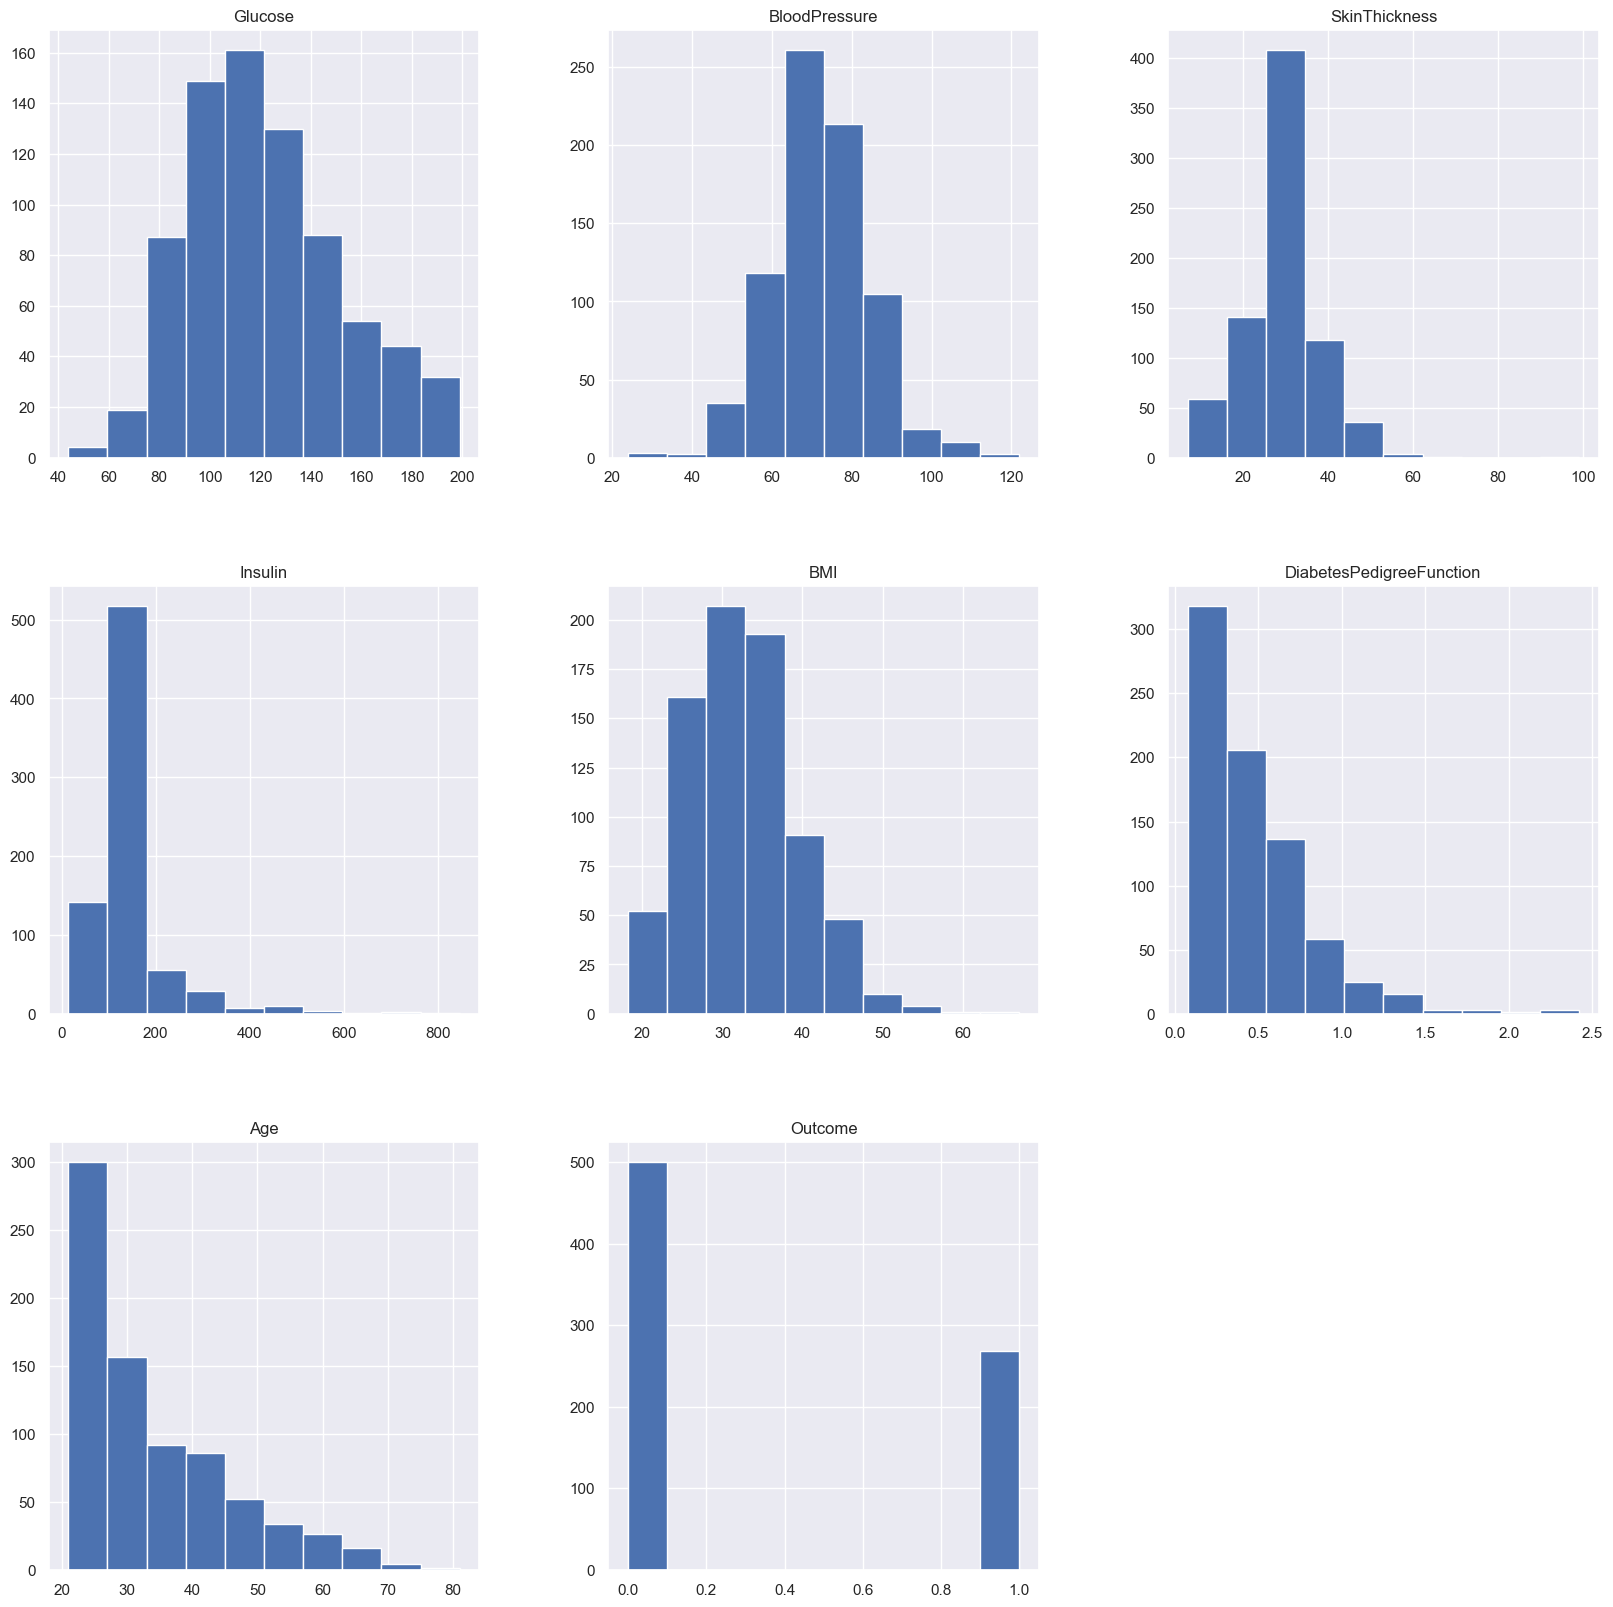

In [59]:
diabetes_df_copy['Glucose'].fillna(diabetes_df_copy['Glucose'].mean(), inplace=True)
diabetes_df_copy['BloodPressure'].fillna(diabetes_df_copy['BloodPressure'].mean(), inplace=True)
diabetes_df_copy['SkinThickness'].fillna(diabetes_df_copy['SkinThickness'].median(), inplace=True)
diabetes_df_copy['Insulin'].fillna(diabetes_df_copy['Insulin'].median(), inplace=True) 
diabetes_df_copy['BMI'].fillna(diabetes_df_copy['BMI'].median(), inplace=True)
diabetes_df_copy.hist(figsize=(20, 20))

In [60]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: missingno in c:\users\ameer\anaconda3\lib\site-packages (0.5.2)



In [61]:
import missingno as msno

<Axes: >

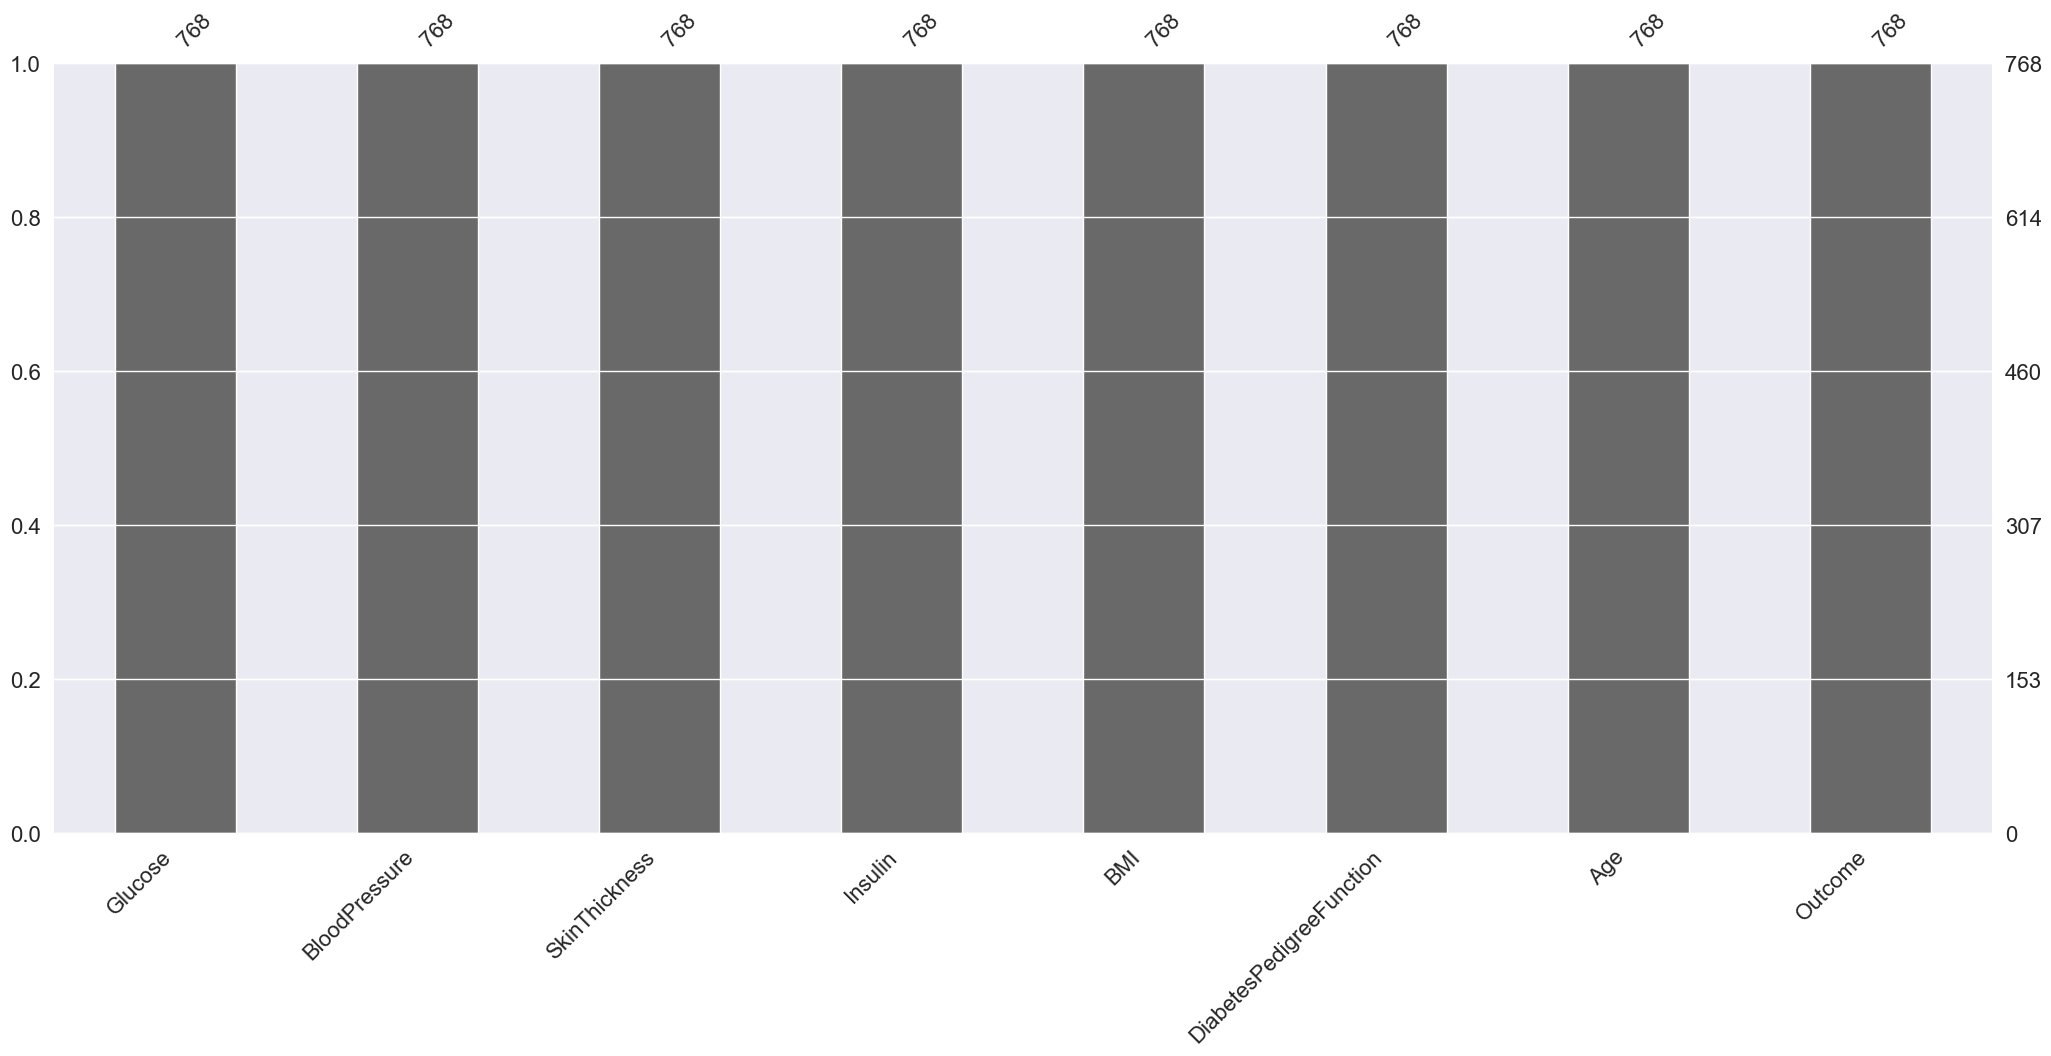

In [62]:
msno.bar(diabetes_df)

Outcome
0    500
1    268
Name: count, dtype: int64


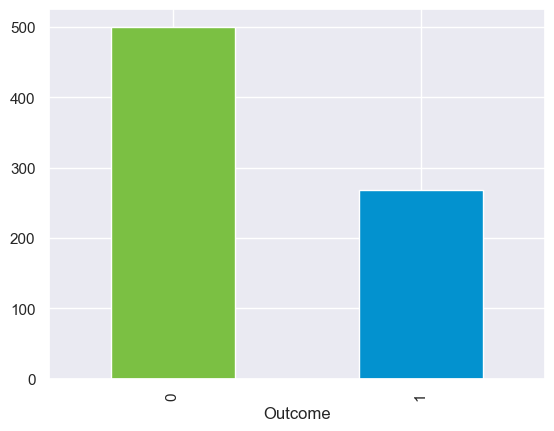

In [63]:
color_wheel = {1: "#0392cf", 2: "#7bc043"}
colors = diabetes_df["Outcome"].map(lambda x: color_wheel.get(x + 1))

print(diabetes_df["Outcome"].value_counts())
p = diabetes_df["Outcome"].value_counts().plot(kind="bar", color=colors)


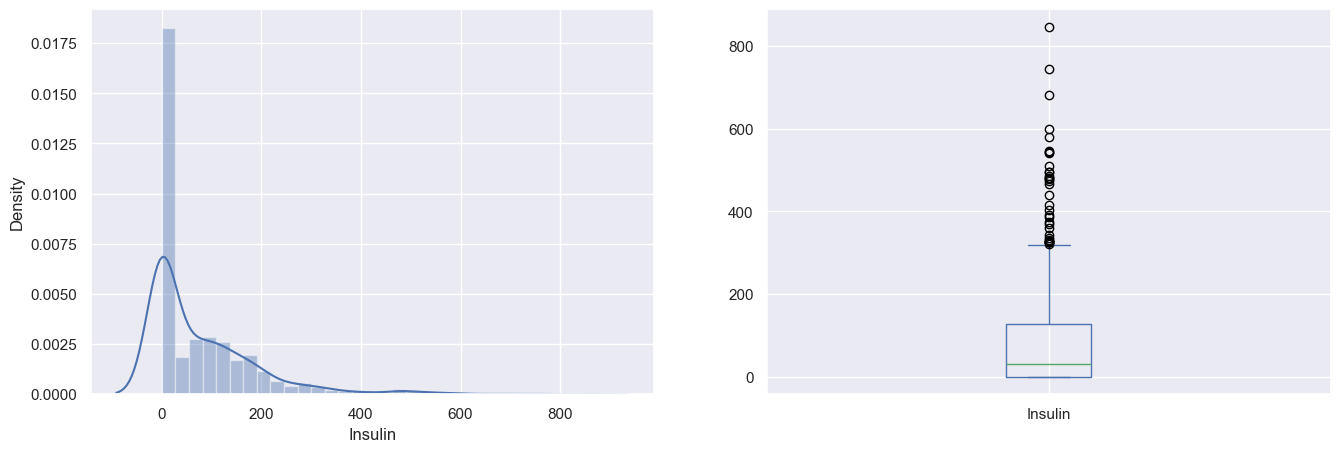

In [64]:
plt.figure(figsize=(16, 5))

plt.subplot(121)
sns.distplot(diabetes_df['Insulin'])

plt.subplot(122)
diabetes_df['Insulin'].plot.box()

plt.show()

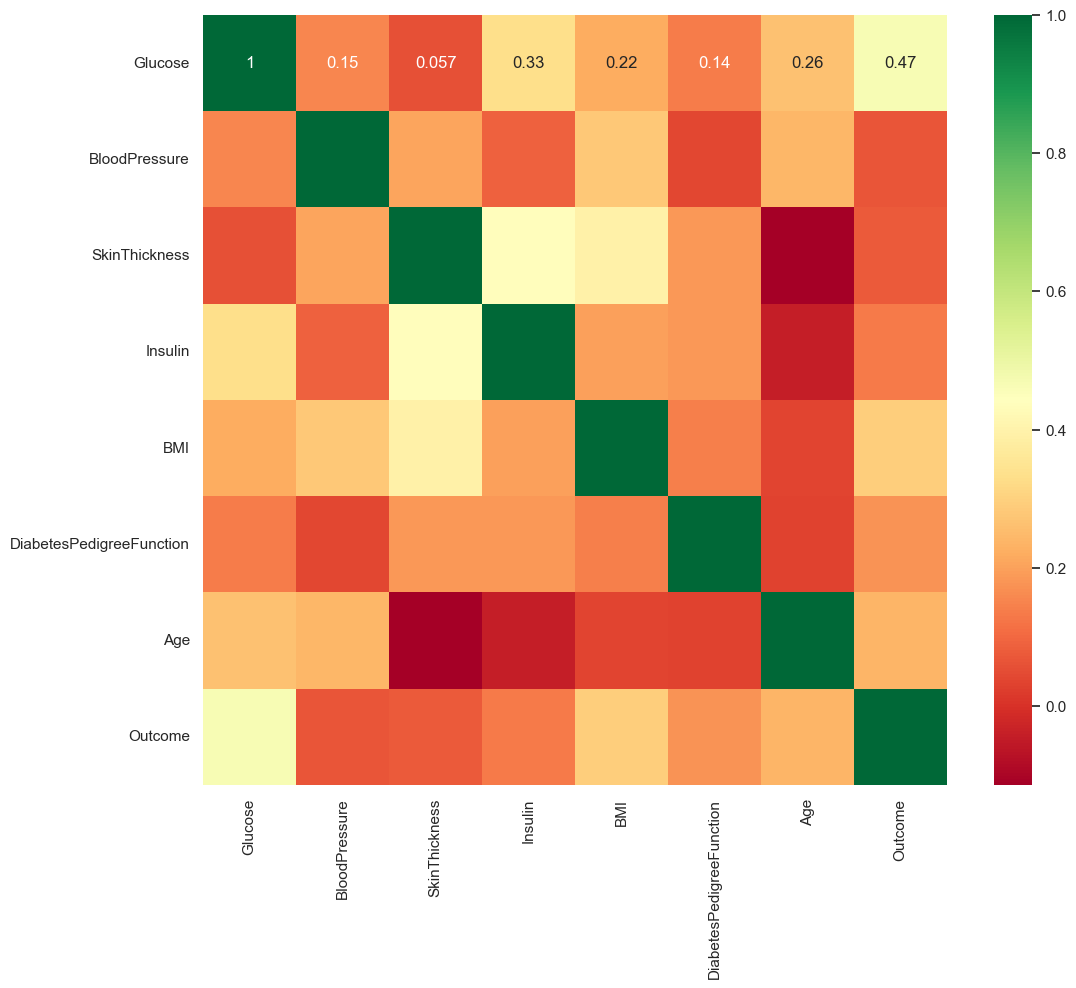

In [65]:
plt.figure(figsize=(12, 10))
sns.heatmap(diabetes_df.corr(), annot=True, cmap='RdYlGn')
plt.show()

In [66]:
diabetes_df_copy.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [68]:
sc_X = StandardScaler()
X = pd.DataFrame(sc_X.fit_transform(diabetes_df_copy.drop(["Outcome"], axis=1)), columns=['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'])
X.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.865108,-0.033518,0.670643,-0.181541,0.166619,0.468492,1.425995
1,-1.206162,-0.529859,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672
2,2.015813,-0.695306,-0.012301,-0.181541,-1.332500,0.604397,-0.105584
3,-1.074652,-0.529859,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549
4,0.503458,-2.680669,0.670643,0.316566,1.549303,5.484909,-0.020496


In [69]:
if 'Outcome' in diabetes_df_copy.columns:
    y = diabetes_df_copy['Outcome']
    print(y)
else:
    print("Column 'Outcome' not found in diabetes_df_copy.")


0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


In [70]:
from sklearn.model_selection import train_test_split

X = diabetes_df.drop('Outcome', axis=1)
y = diabetes_df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=7)


In [71]:
from sklearn.ensemble import RandomForestClassifier


rfc = RandomForestClassifier(n_estimators=200)

rfc.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200)

In [72]:
rfc_train = rfc.predict(X_train)
from sklearn import metrics
print("Accuracy =", format(metrics.accuracy_score(y_train, rfc_train)))


Accuracy = 1.0


In [73]:
# Import metrics from sklearn
from sklearn import metrics

# Predict the target variable for the test set
predictions = rfc.predict(X_test)

# Calculate and print the accuracy score
print("Accuracy_Score =", format(metrics.accuracy_score(y_test, predictions)))


Accuracy_Score = 0.7559055118110236


In [74]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test,predictions))

[[135  27]
 [ 35  57]]
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       162
           1       0.68      0.62      0.65        92

    accuracy                           0.76       254
   macro avg       0.74      0.73      0.73       254
weighted avg       0.75      0.76      0.75       254



In [75]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

In [76]:
dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

DecisionTreeClassifier()

In [77]:
predictions = dtree.predict(X_test)

In [78]:
print("Accuracy Score =", format(metrics.accuracy_score(y_test, predictions)))

Accuracy Score = 0.7125984251968503


In [79]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions))


Confusion Matrix:
[[127  35]
 [ 38  54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.78      0.78       162
           1       0.61      0.59      0.60        92

    accuracy                           0.71       254
   macro avg       0.69      0.69      0.69       254
weighted avg       0.71      0.71      0.71       254



In [80]:
from sklearn.svm import SVC
from sklearn import metrics

In [81]:
svc_model = SVC()
svc_model.fit(X_train, y_train)

SVC()

In [82]:
svc_pred = svc_model.predict(X_test)

In [83]:
print("Accuracy Score =", format(metrics.accuracy_score(y_test, svc_pred)))

Accuracy Score = 0.7519685039370079


In [84]:
from sklearn.metrics import classification_report, confusion_matrix

In [85]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, svc_pred))

Confusion Matrix:
[[146  16]
 [ 47  45]]


In [86]:
print("\nClassification Report:")
print(classification_report(y_test, svc_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.90      0.82       162
           1       0.74      0.49      0.59        92

    accuracy                           0.75       254
   macro avg       0.75      0.70      0.71       254
weighted avg       0.75      0.75      0.74       254



In [87]:
rfc.feature_importances_

array([0.28529393, 0.09524416, 0.07909861, 0.07829335, 0.17444573,
       0.13623359, 0.15139063])

<Axes: >

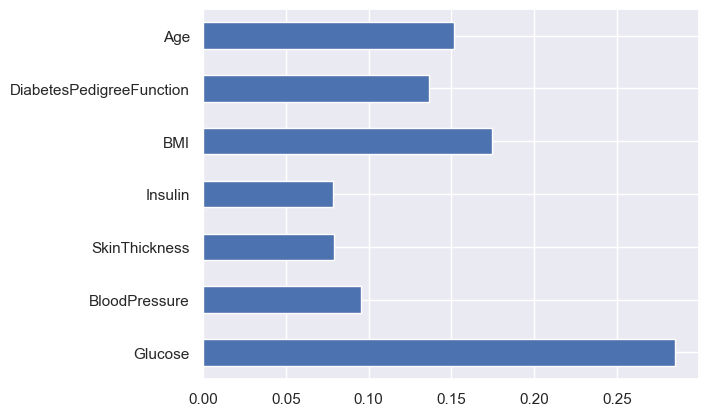

In [88]:
feature_importance_series = pd.Series(rfc.feature_importances_, index=X.columns)
feature_importance_series.plot(kind='barh')

In [89]:
import pickle

saved_model = pickle.dumps(rfc)

rfc_from_pickle = pickle.loads(saved_model)
rfc_from_pickle.predict(X_test)


array([0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1], dtype=int64)

In [90]:
diabetes_df.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
2,183,64,0,0,23.3,0.672,32,1
3,89,66,23,94,28.1,0.167,21,0
4,137,40,35,168,43.1,2.288,33,1


In [91]:
diabetes_df.tail()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,101,76,48,180,32.9,0.171,63,0
764,122,70,27,0,36.8,0.340,27,0
765,121,72,23,112,26.2,0.245,30,0
766,126,60,0,0,30.1,0.349,47,1
767,93,70,31,0,30.4,0.315,23,0


In [96]:
rfc.predict([[137,40,35,168,43.1,2.228,33]])

array([1], dtype=int64)

In [98]:
rfc.predict([[101,76,48,180,32.9,0.171,63]])

array([0], dtype=int64)